<a href="https://colab.research.google.com/github/MelanieDN/Airbnb/blob/main/Analyse_exploratoire_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Setup

## 📚 Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data viz
import matplotlib.pyplot as plt
import seaborn as sns

## 🎨 Visual style settings

In [ ]:
sns.set(style="whitegrid")

## 💾 Load Dataset

In [ ]:
listing_df = pd.read_csv("/content/bquxjob_1e49da90_19bff11fef9.csv")
calendar_df = pd.read_csv("/content/bquxjob_6136a59c_19bff115b2a.csv")

#🕵️EDA



## 🔍 Overview

In [ ]:
listing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   listing_id           500 non-null    int64  
 1   room_type            500 non-null    object 
 2   host_response_time   500 non-null    object 
 3   review_scores_value  500 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 15.8+ KB


In [ ]:
calendar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72101 entries, 0 to 72100
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   listing_id  72101 non-null  int64 
 1   date_date   72101 non-null  object
 2   available   72101 non-null  bool  
 3   price       72101 non-null  int64 
dtypes: bool(1), int64(2), object(1)
memory usage: 1.7+ MB


In [ ]:
listing_df.head()


,listing_id,room_type,host_response_time,review_scores_value
0,5396,Entire home/apt,within an hour,4.54
1,7397,Entire home/apt,within an hour,4.72
2,9952,Entire home/apt,within an hour,4.90
3,10586,Entire home/apt,within a day,4.67
4,10588,Entire home/apt,within a day,4.67


In [ ]:
calendar_df.sort_values(by='date_date',ascending=True).head()

,listing_id,date_date,available,price
18168,195564,2022-09-09,False,79
18601,205140,2022-09-09,False,120
61827,629392,2022-09-09,False,95
45423,513757,2022-09-09,False,120
19034,209796,2022-09-09,False,60


In [ ]:
calendar_df.describe()

# allows to get an overview of the columns

,listing_id,price
count,72101.00000,72101.000000
mean,388082.92738,158.020041
std,225915.25176,142.359070
min,5396.00000,30.000000
25%,193632.00000,85.000000
50%,422295.00000,120.000000
75%,566867.00000,175.000000
max,788259.00000,4000.000000


In [ ]:
listing_df.describe()

,listing_id,review_scores_value
count,500.000000,500.000000
mean,388076.454000,4.667060
std,226149.842829,0.227179
min,5396.000000,2.330000
25%,193264.500000,4.580000
50%,421638.000000,4.700000
75%,566872.250000,4.800000
max,788259.000000,5.000000


In [ ]:
listing_df.nunique()

,0
listing_id,500
room_type,3
host_response_time,4
review_scores_value,78


In [ ]:
calendar_df.nunique()

,0
listing_id,500
date_date,145
available,2
price,352


## 👥 Duplicated values?

In [ ]:
nb_of_duplicated_rows = listing_df.duplicated().sum()
nb_of_duplicated_rows

np.int64(0)

In [ ]:
nb_of_duplicated_rows = calendar_df.duplicated().sum()
nb_of_duplicated_rows

np.int64(0)

## ❓ Missing values?

In [ ]:
listing_df.isnull().sum()

,0
listing_id,0
room_type,0
host_response_time,0
review_scores_value,0


In [ ]:
calendar_df.isnull().sum()

,0
listing_id,0
date_date,0
available,0
price,0


## 👍 Univariate Analysis

### 💯 review score value

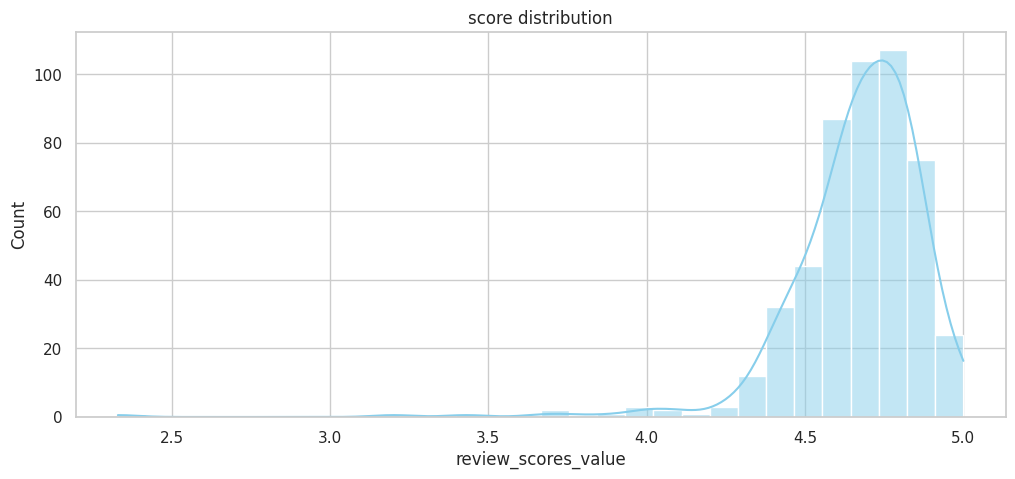

In [ ]:
# understanding the distribution and looking for potential outliers

plt.figure(figsize=(12,5))
sns.histplot(listing_df['review_scores_value'].dropna(), kde=True, bins=30, color='skyblue')
plt.title("score distribution")
plt.xlabel('review_scores_value')
plt.show()

<Axes: >

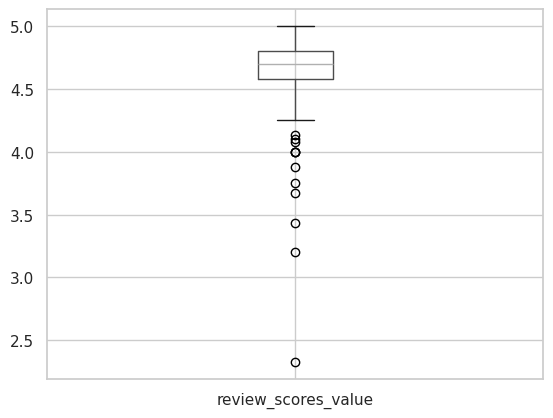

In [ ]:
listing_df[['review_scores_value']].boxplot()

### 💰 Price

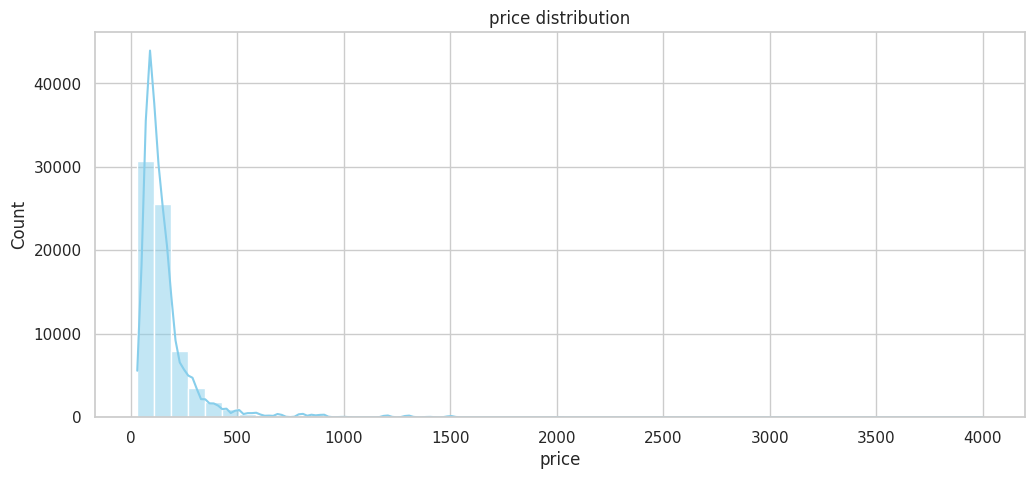

In [ ]:
# understanding the distribution and looking for potential outliers

plt.figure(figsize=(12,5))
sns.histplot(calendar_df['price'].dropna(), kde=True, bins=50, color='skyblue')
plt.title("price distribution")
plt.xlabel('price')
plt.show()

<Axes: >

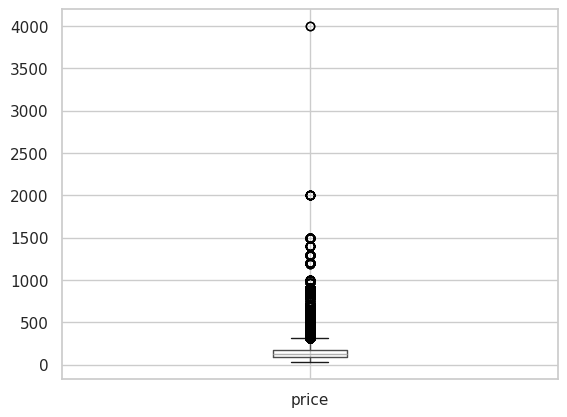

In [ ]:
calendar_df[['price']].boxplot()

In [ ]:
#removing the data with prices over 1000€
#that represent a really small part of the offer (arround 0,48 %)
#in order to get a clearer view
filtered_calendar_df = calendar_df[calendar_df['price'] < 1000]

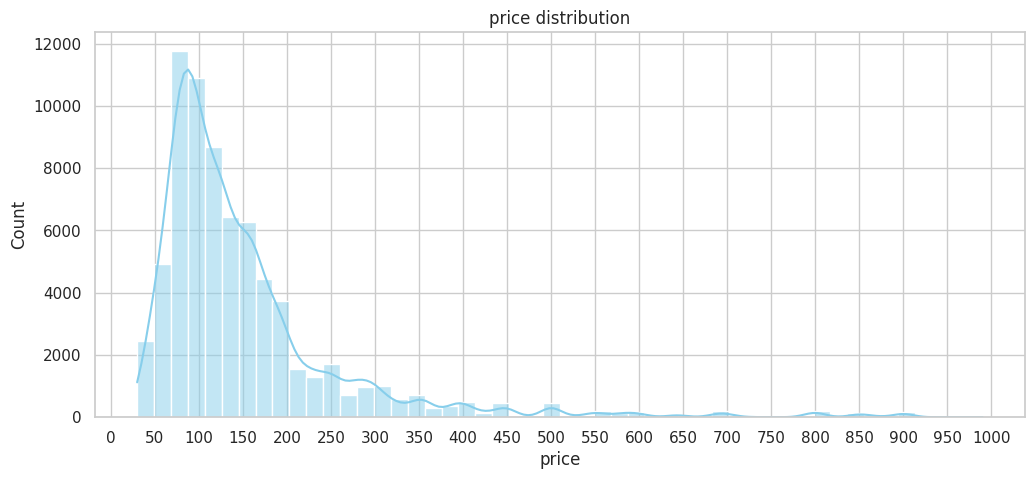

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(filtered_calendar_df['price'].dropna(), kde=True, bins=50, color='skyblue')
plt.title("price distribution")
plt.xlabel('price')
plt.xticks(np.arange(0, 1001, 50))
plt.show()

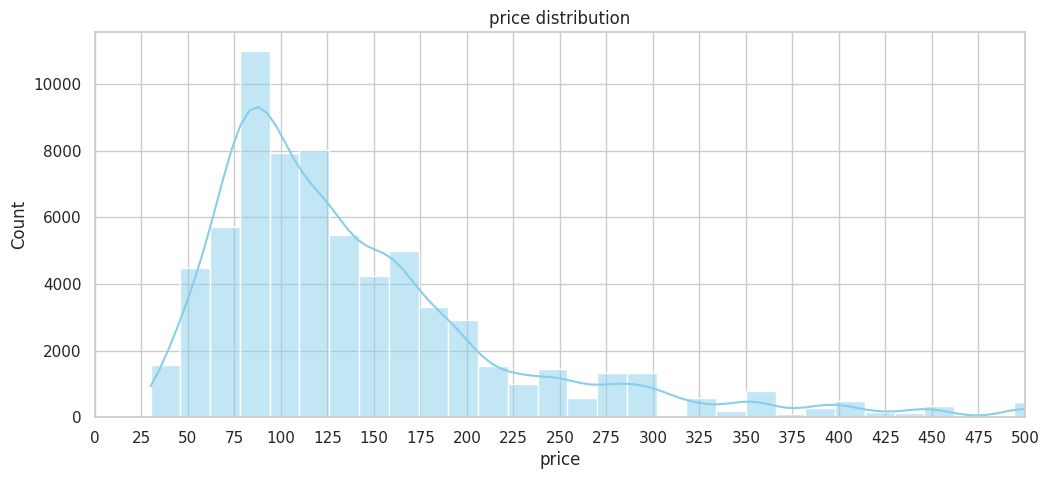

In [ ]:
#zoom on the prices bellow 500€
plt.figure(figsize=(12,5))
sns.histplot(filtered_calendar_df['price'].dropna(), kde=True, bins=60, color='skyblue')
plt.title("price distribution")
plt.xlabel('price')
plt.xticks(np.arange(0, 1001, 25))
plt.xlim(0, 500)
plt.show()


### ⌛ Response time

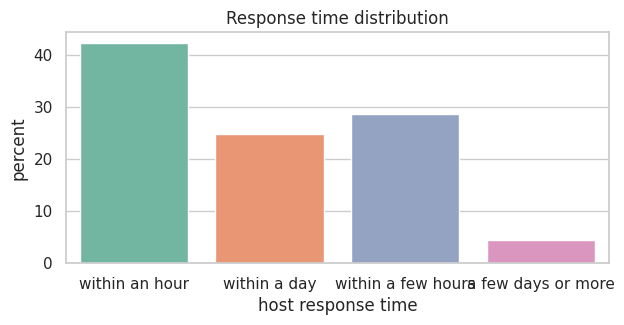

In [ ]:
plt.figure(figsize=(7,3))
sns.countplot(x='host_response_time',data=listing_df, hue = 'host_response_time', legend = False, palette='Set2',stat="percent")
plt.title('Response time distribution')
plt.xlabel('host response time')
plt.show()

## 🖥️ Correlation

In [ ]:
merged_df = calendar_df.merge(listing_df, how = 'left', on = 'listing_id')

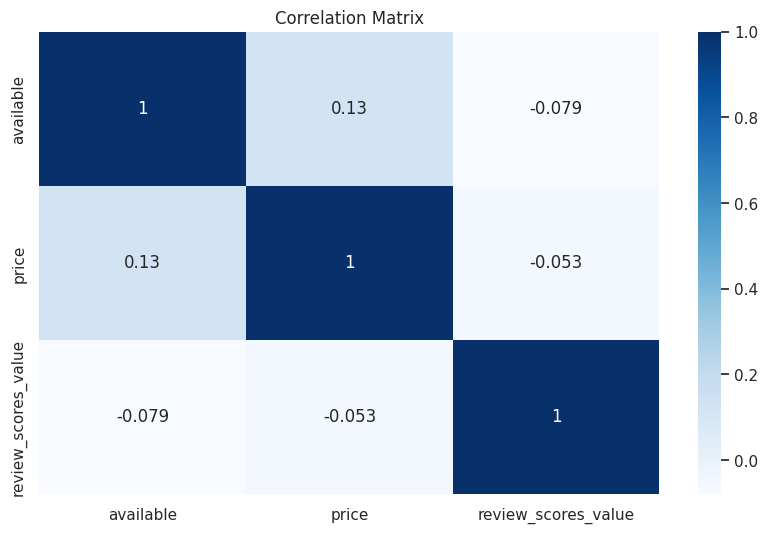

In [ ]:
#Checking for correlation between availability, price and review soces

corr_matrix = merged_df[['available','price','review_scores_value']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

# Conclusions


Airbnb data from 2022-09-09 to 2023-01-31\
No null values and no dupes\
listing_id = primary key of the listing table
\
\
The mean revue score is 4.66 and the majority of the notes are between 4,6 and 4,8.\
Only 25% of the notes are under 4,58 and the lower one is 2.33.
\
\
The range of prices is very large going from 30€ to 4000€ but 50% of the rentals are between 75 et 175€.
\
\
The hosts are globaly reactive with 70% of them answering within hours.
\
\
There is a correlation between the price and the availability. the higher the price, the higher are the chances that it won't be rented.\
However, this is a small correlation.
\
\
There is also a discrete correlation between the score review and the availability. The accomodations with good reviews tend to be more rented.
\
\
Price and rating appear to be factors influencing reservations, but given the weak correlation, other elements must be taken into account.
Our analysis will therefore also need to consider the host's response time and the type of accommodation.